In [1]:
import os
import numpy as np
import getdist
from getdist import plots, MCSamples
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib import cm
from pathlib import Path

In [2]:
def phi2_final(c):
    """
    Calculates phi^2_final based on the coupling constant c (xi).
    
    Formula:
    1 / (8*c + 3*sqrt(c*(c + 18) + 9) + 9)
    """
    xi = c
    
    # Calculate the term inside the square root first
    # xi * (xi + 18) + 9
    sqrt_arg = xi * (xi + 18) + 9
    sqrt_term = np.sqrt(sqrt_arg)
    
    # Calculate the denominator
    # 8*xi + 3*sqrt(...) + 9
    denominator = 8 * xi + 3 * sqrt_term + 9
    
    return 1.0 / denominator

In [3]:
def phi2_initial(N, c):
    """
    Calculates phi^2_initial based on N and c (xi).
    
    Formula:
    (0.0909091 - 0.0909091 * exp(-7.3332 * xi * N) * (1 - 11 * xi * phi_f^2)^0.999981) / xi
    """
    # 1. Get phi_final squared
    phi_f_sq = phi2_final(c)
    
    # 2. Define xi
    xi = c
    
    # 3. Calculate the base term for the exponent
    # (1. - 11. * xi * phi_f^2)
    base_term = 1.0 - 11.0 * xi * phi_f_sq
    
    # 4. Calculate the exponential part
    # exp(-7.3332 * xi * N)
    exp_part = np.exp(-7.3332 * xi * N)
    
    # 5. Combine terms in the numerator
    # 0.0909091 * exp_part * base_term^0.999981
    term2 = 0.0909091 * exp_part * (base_term**0.999981)
    
    # Numerator: 0.0909091 - term2
    numerator = 0.0909091 - term2
    
    # 6. Final result
    return numerator / xi

In [4]:
def ns_func(N, s, c):
    """
    Calculates the scalar spectral index n_s based on N and c (xi)
    using specific numerical constants.
    
    Formula:
    xi * ( (7.9997 / (1. * xi * phi_i^2 + 1.)) - 13.4442 ) - (0.777776 / phi_i^2) + 0.99985
    """
    # 1. Get phi_initial squared
    phi_i_sq = phi2_initial(N, c)
    
    # 2. Define xi
    xi = c
    
    # 3. Calculate the bracket term
    # (7.9997 / (1. * xi * phi_i^2 + 1.)) - 13.4442
    denom = (1.0 * xi * phi_i_sq) + 1.0
    bracket = (7.9997 / denom) - 13.4442
    
    # 4. Calculate the main terms
    term1 = xi * bracket
    term2 = 0.777776 / phi_i_sq
    term3 = 0.99985
    
    # 5. Final result
    return term1 - term2 + term3

In [5]:
def alpha_s_func(N, s, c):
    """
    Calculates the running of the scalar spectral index alpha_s 
    based on N and c (xi).
    """
    # 1. Get phi_final squared
    phi_f_sq = phi2_final(c)
    
    # 2. Define xi and base terms
    xi = c
    base_term = 1.0 - 11.0 * xi * phi_f_sq
    
    # 3. Calculate exponential factor E = exp(7.3332 * xi * N)
    # The formula uses multiples: 7.3332, 14.6664 (2x), 21.9996 (3x)
    E = np.exp(7.3332 * xi * N)
    E2 = E**2  # exp(14.6664 * xi * N)
    E3 = E**3  # exp(21.9996 * xi * N)
    
    # --- NUMERATOR ---
    # Common factor: xi^2
    
    # Term 1: -3.44709 * E * base^2.99994
    n1 = -3.44709 * E * (base_term**2.99994)
    
    # Term 2: -1.27309 * E^2 * base^1.99996
    n2 = -1.27309 * E2 * (base_term**1.99996)
    
    # Term 3: 49.6401 * E^3 * base^0.999981
    n3 = 49.6401 * E3 * (base_term**0.999981)
    
    numerator = (xi**2) * (n1 + n2 + n3)
    
    # --- DENOMINATOR ---
    # The whole expression is squared at the end
    
    # Term 1: 0.0769231 * base^1.99996
    d1 = 0.0769231 * (base_term**1.99996)
    
    # Term 2: -1. * E * base^0.999981
    d2 = -1.0 * E * (base_term**0.999981)
    
    # Term 3: 0.923077 * E^2
    d3 = 0.923077 * E2
    
    denominator = (d1 + d2 + d3)**2
    
    return numerator / denominator

Loading Planck...
Loading ACT...
Calculating trajectories...

Plot saved to alpha_s_vs_ns_1_3.pdf


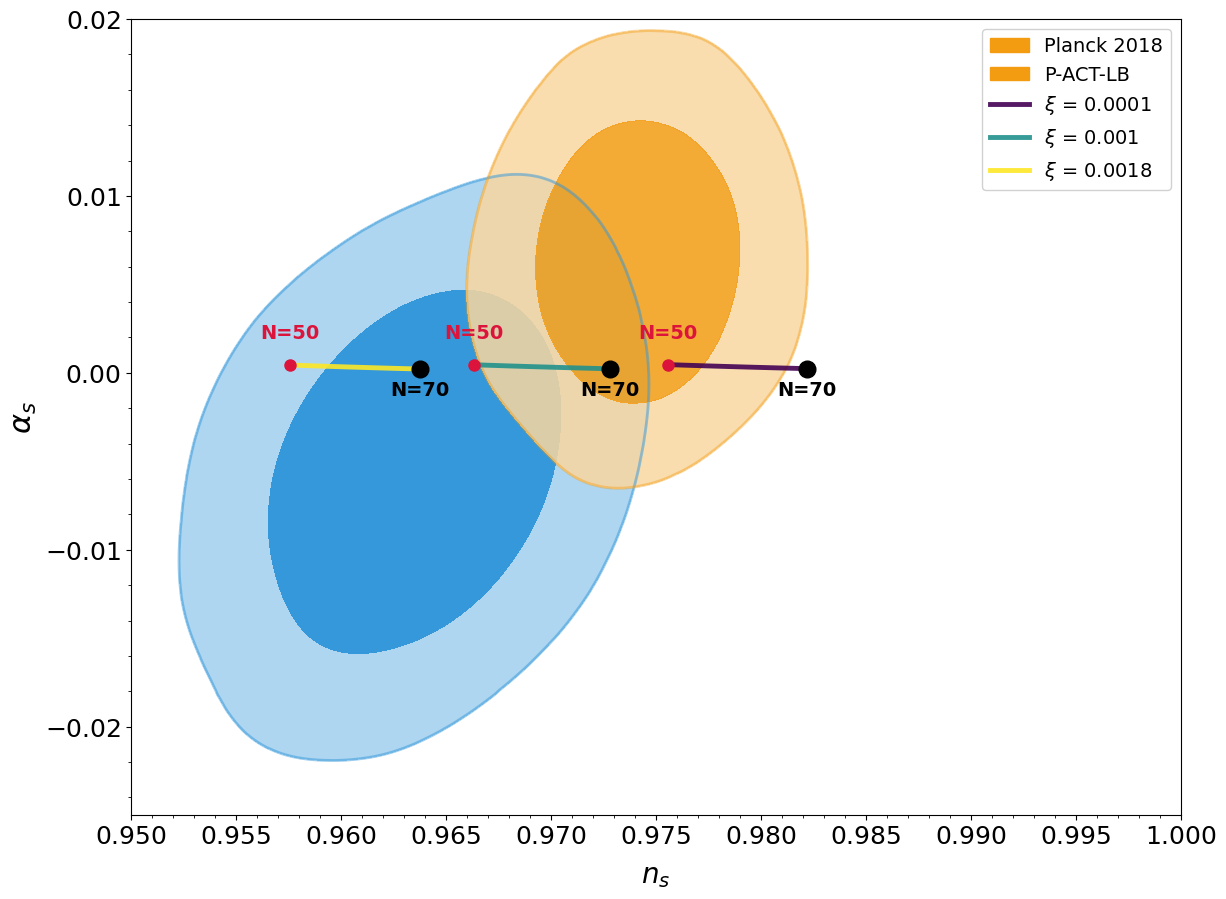

In [6]:
# --- 2. SETUP PATHS ---
notebook_dir = Path.cwd()

base_dir = notebook_dir.parents[1] / "data"
act_path = os.path.join(base_dir, 'p-actlite-l-b_nrun_camb', 'p-actlite-l-b_nrun_camb')
planck_path = os.path.join(base_dir, 'COM_CosmoParams_fullGrid_R3.01', 'base_nrun', 'plikHM_TTTEEE_lowl_lowE', 'base_nrun_plikHM_TTTEEE_lowl_lowE')

# --- 3. LOAD DATA ---
samples_to_plot = []

try:
    print("Loading Planck...")
    planck_samples = getdist.mcsamples.loadMCSamples(planck_path, settings={'ignore_rows': 0.3})
    planck_samples.updateSettings({'label': 'Planck 2018'}) 
    samples_to_plot.append(planck_samples)
except:
    print("Warning: Planck data not found.")

try:
    print("Loading ACT...")
    act_samples = getdist.mcsamples.loadMCSamples(act_path, settings={'ignore_rows': 0.3})
    act_samples.updateSettings({'label': 'P-ACT-LB'})
    samples_to_plot.append(act_samples)
except:
    print("Warning: ACT data not found.")

# --- 4. PLOT ---
if len(samples_to_plot) > 0:
    g = plots.get_single_plotter(width_inch=12, ratio=0.75)
    
    # Settings
    g.settings.num_plot_contours = 2
    g.settings.axes_fontsize = 18
    g.settings.lab_fontsize = 20
    g.settings.legend_fontsize = 15
    
    # COLORS: Planck (Grey), ACT (Blue)
    g.settings.solid_colors = ['#F39C12','#3498DB'] 

    g.plot_2d(samples_to_plot, param1='ns', param2='nrun', filled=True)
    ax = g.subplots[0,0]

    ax.set_ylabel(r'$\alpha_s$', fontsize=22)
    
    # --- 5. PLOT TRAJECTORIES ---
    print("Calculating trajectories...")
    s_fixed = 0.76
    #c_values = [0.00001,0.0005, 0.001, 0.0015, 0.003, 0.005, 0.007, 0.01, 0.02, 0.03, 0.04] 
    c_values = [0.0001,0.001,0.0018]
    line_colors = [cm.viridis(i) for i in np.linspace(0, 1, len(c_values))]
    
    N_range = np.linspace(50, 70, 100) 
    
    for c, color in zip(c_values, line_colors):
        ns_line = []
        alpha_line = []
        for N in N_range:
            ns_line.append(ns_func(N, s_fixed, c))
            alpha_line.append(alpha_s_func(N, s_fixed, c))
        
        ax.plot(ns_line, alpha_line, color=color, lw=3.5, alpha=0.9, label=rf'$\xi$ = {c:.2g}')
        ax.plot(ns_line[0], alpha_line[0], 'o', color='crimson', markersize=8)
        ax.text(ns_line[0], alpha_line[0] + 0.0015, 'N=50', color='crimson', fontsize=14, weight='bold', ha='center')
        ax.plot(ns_line[-1], alpha_line[-1], 'o', color='black', markersize=12)
        ax.text(ns_line[-1], alpha_line[-1] - 0.0015, 'N=70', color='black', fontsize=14, weight='bold', ha='center')

    # Label N=50 and N=70
    ns_0 = ns_func(50, s_fixed, c_values[0])
    al_0 = alpha_s_func(50, s_fixed, c_values[0])
    #ax.text(ns_0, al_0 + 0.0015, 'N=50', color='black', fontsize=14, weight='bold', ha='center')

    ns_end = ns_func(70, s_fixed, c_values[0])
    al_end = alpha_s_func(70, s_fixed, c_values[0])
    #ax.text(ns_end, al_end + 0.0015, 'N=70', color='black', fontsize=14, weight='bold', ha='center')

    # --- 6. TICKS & LIMITS ---
    ax.set_xlim(0.95, 1.0)
    ax.set_ylim(-0.025, 0.02)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.005))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.001))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # --- 7. CREATE LEGEND MANUALLY (FIXED COLORS) ---
    
    # Manually create patches with the CORRECT colors
    planck_patch = mpatches.Patch(color='#F39C12', label='Planck 2018') # Grey
    act_patch = mpatches.Patch(color='#F39C12', label='P-ACT-LB')       # Blue
    
    # Get handles for the trajectory lines
    line_handles, line_labels = ax.get_legend_handles_labels()
    
    # Combine: [Data Patches] + [Line Handles]
    all_handles = [planck_patch, act_patch] + line_handles
    all_labels = ['Planck 2018', 'P-ACT-LB'] + line_labels

    
    ax.legend(handles=all_handles, labels=all_labels, loc='upper right', fontsize=14, framealpha=0.9)

    outfile = 'alpha_s_vs_ns_1_3.pdf'
    g.export(outfile, dpi=300)
    print(f"\nPlot saved to {outfile}")
else:
    print("No data loaded.")